In [1]:
# Frozen logistic base + explicit cell correction + tiny residual NN
# final_logit = alpha * frozen_base_logit + cell_delta(cell_id) + tiny residual NN


# 1 - Environment
import subprocess, sys, os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

pkgs = [
    "torch", "scikit-learn", "pandas", "numpy", "matplotlib",
    "seaborn", "shap", "scipy", "statsmodels", "nbformat"
]
for p in pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", p, "-q"])
print("Done.")

Done.


In [2]:
# 2 - Configuration and Imports
CSV_PATH           = "brfss2024_clean_20260402.csv"
SEED               = 42
WEIGHT_TRIM_PCT    = 99
RELIABLE_N         = 30
MI_DATASETS        = 5
ALPHA_CONFORMAL    = 0.10

BASE_C             = 1.0
BASE_MAX_ITER      = 2000

HIDDEN_DIMS        = [32, 16]
DROPOUT            = 0.03
LR                 = 8e-4
WEIGHT_DECAY       = 1e-4
BATCH_SIZE         = 2048
MAX_EPOCHS         = 100
PATIENCE           = 15
NUM_WORKERS        = 4

STATE_EMB_DIM      = 4

# Cell correction is the main learned NN piece
CELL_EMB_DIM       = 6
CELL_DELTA_L2      = 0.03
CELL_MEAN_LAMBDA   = 2.0
CELL_BATCH_MINN    = 8
FULL_CELL_TARGET_LAMBDA = 12.0
FULL_CELL_TARGET_STEPS  = 2
EARLY_STOP_CELL_WEIGHT  = 0.25

# Tiny residual NN
RESIDUAL_SCALE     = 0.01
RESIDUAL_L2_LAMBDA = 0.25
ALPHA_LAMBDA       = 0.10

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import chi2_contingency

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression as SKLogistic
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

PyTorch device: cuda
  GPU: NVIDIA A100-SXM4-80GB
  VRAM: 85.1 GB


In [3]:
# 3 - Load and Clean
KEEP_COLS = [
    "_STATE", "_BMI5CAT", "_BMI5",
    "_SEX", "_AGEG5YR", "_RACE", "_EDUCAG", "_INCOMG1",
    "_LLCPWT", "_STSTR", "_PSU"
]

df_raw = pd.read_csv(CSV_PATH, usecols=KEEP_COLS, low_memory=False)
print(f"Raw shape: {df_raw.shape}")

MISSING_CODES = {
    "_BMI5":    [9999],
    "_AGEG5YR": [14],
    "_RACE":    [9],
    "_EDUCAG":  [9],
    "_INCOMG1": [9],
}
df = df_raw.copy()
for col, codes in MISSING_CODES.items():
    df[col] = df[col].replace(codes, np.nan)

bmi_actual = df["_BMI5"] / 100
implausible = (bmi_actual < 10) | (bmi_actual > 80)
print(f"Implausible BMI removed: {implausible.sum():,}")
df.loc[implausible, ["_BMI5", "_BMI5CAT"]] = np.nan

df["obese"] = np.where(
    df["_BMI5"] / 100 >= 30.0, 1.0,
    np.where(df["_BMI5"].isna(), np.nan, 0.0)
)

df = df.dropna(subset=["obese", "_LLCPWT"]).reset_index(drop=True)

print(f"Clean shape:       {df.shape}")
print(f"Obese prevalence:  {df['obese'].mean()*100:.1f}%")
print(f"Missing _INCOMG1:  {df['_INCOMG1'].isna().sum():,} ({df['_INCOMG1'].isna().mean()*100:.1f}%)")
print(f"Missing _AGEG5YR:  {df['_AGEG5YR'].isna().sum():,} ({df['_AGEG5YR'].isna().mean()*100:.1f}%)")

CAT_FEATURES = ["_SEX", "_AGEG5YR", "_RACE", "_EDUCAG", "_INCOMG1"]
CELL_COLS = CAT_FEATURES[:]
VALID_CODES = {
    "_SEX":     [1, 2],
    "_AGEG5YR": list(range(1, 14)),
    "_RACE":    list(range(1, 9)),
    "_EDUCAG":  [1, 2, 3, 4],
    "_INCOMG1": list(range(1, 8)),
}
RACE_LABELS = {
    1: "NH-White", 2: "NH-Black", 3: "AIAN", 4: "Asian",
    5: "NHOPI", 6: "Other", 7: "Multiracial", 8: "Hispanic"
}

def get_factor_arrays(df_imp):
    return {
        "sex": df_imp["_SEX"].fillna(0).astype(int).values,
        "age": df_imp["_AGEG5YR"].fillna(0).astype(int).values,
        "race": df_imp["_RACE"].fillna(0).astype(int).values,
        "educ": df_imp["_EDUCAG"].fillna(0).astype(int).values,
        "income": df_imp["_INCOMG1"].fillna(0).astype(int).values,
    }

Raw shape: (457670, 11)
Implausible BMI removed: 103
Clean shape:       (414530, 12)
Obese prevalence:  33.7%
Missing _INCOMG1:  63,509 (15.3%)
Missing _AGEG5YR:  4,484 (1.1%)


=== Chi-square: is missingness independent of observed variables? ===
p < 0.05 rejects MCAR

  _INCOMG1 missing X _SEX: chi2=600.4  p=0.0000  *** MCAR REJECTED
  _INCOMG1 missing X _RACE: chi2=325.1  p=0.0000  *** MCAR REJECTED
  _INCOMG1 missing X _EDUCAG: chi2=2760.3  p=0.0000  *** MCAR REJECTED
  _INCOMG1 missing X _STATE: chi2=1887.0  p=0.0000  *** MCAR REJECTED

  _AGEG5YR missing X _SEX: chi2=47.0  p=0.0000  *** MCAR REJECTED
  _AGEG5YR missing X _RACE: chi2=204.2  p=0.0000  *** MCAR REJECTED
  _AGEG5YR missing X _EDUCAG: chi2=87.2  p=0.0000  *** MCAR REJECTED
  _AGEG5YR missing X _STATE: chi2=374.3  p=0.0000  *** MCAR REJECTED

Missingness indicators added to df
Trim threshold (p99): 5,182.5
Records trimmed:  4,146 (1.00%)
ESS before:       80,942
ESS after:        122,961

National DEFF: 0.002  (expected 1.5-2.5 for BRFSS national estimates)
  sqrt(DEFF) = 0.043  (SE inflation factor for reported CIs)


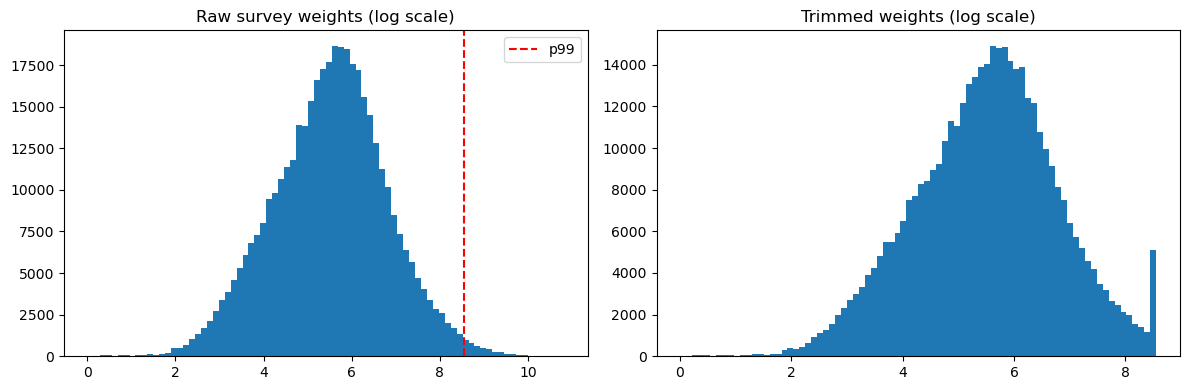

In [4]:
# 4 - Missing Data Mechanism Test (MCAR chi-square)
print("=== Chi-square: is missingness independent of observed variables? ===")
print("p < 0.05 rejects MCAR\n")

for missing_col in ["_INCOMG1", "_AGEG5YR"]:
    flag = df[missing_col].isna().astype(int)
    for predictor in ["_SEX", "_RACE", "_EDUCAG", "_STATE"]:
        obs = df[predictor].dropna()
        idx = obs.index.intersection(flag.index)
        ct = pd.crosstab(flag.loc[idx], obs.loc[idx])
        if ct.shape[1] < 2:
            continue
        chi2, p, _, _ = chi2_contingency(ct)
        sig = "*** MCAR REJECTED" if p < 0.05 else "OK"
        print(f"  {missing_col} missing X {predictor}: chi2={chi2:.1f}  p={p:.4f}  {sig}")
    print()

df["_INCOMG1_missing"] = df["_INCOMG1"].isna().astype(float)
df["_AGEG5YR_missing"] = df["_AGEG5YR"].isna().astype(float)
print("Missingness indicators added to df")

# 5 - Survey Weight Trimming and Design Effect
p_trim = np.percentile(df["_LLCPWT"], WEIGHT_TRIM_PCT)
df["_LLCPWT_trimmed"] = np.clip(df["_LLCPWT"], None, p_trim)
df["_LLCPWT_s"] = df["_LLCPWT_trimmed"] / df["_LLCPWT_trimmed"].mean()

ESS_before = df["_LLCPWT"].sum()**2 / (df["_LLCPWT"]**2).sum()
ESS_after  = df["_LLCPWT_trimmed"].sum()**2 / (df["_LLCPWT_trimmed"]**2).sum()
n_trimmed   = (df["_LLCPWT"] > p_trim).sum()

print(f"Trim threshold (p{WEIGHT_TRIM_PCT}): {p_trim:,.1f}")
print(f"Records trimmed:  {n_trimmed:,} ({n_trimmed/len(df)*100:.2f}%)")
print(f"ESS before:       {ESS_before:,.0f}")
print(f"ESS after:        {ESS_after:,.0f}")

y_arr = df["obese"].values
w_arr = df["_LLCPWT_trimmed"].values
p_hat_n = np.average(y_arr, weights=w_arr)
var_wt = np.average((y_arr - p_hat_n)**2, weights=w_arr) / (w_arr.sum() - 1)
var_srs = p_hat_n * (1 - p_hat_n) / len(y_arr)
DEFF = var_wt / var_srs
print(f"\nNational DEFF: {DEFF:.3f}  (expected 1.5-2.5 for BRFSS national estimates)")
print(f"  sqrt(DEFF) = {np.sqrt(DEFF):.3f}  (SE inflation factor for reported CIs)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(np.log1p(df["_LLCPWT"]), bins=80, edgecolor="none")
axes[0].axvline(np.log1p(p_trim), color="red", linestyle="--", label=f"p{WEIGHT_TRIM_PCT}")
axes[0].set_title("Raw survey weights (log scale)")
axes[0].legend()
axes[1].hist(np.log1p(df["_LLCPWT_trimmed"]), bins=80, edgecolor="none")
axes[1].set_title("Trimmed weights (log scale)")
plt.tight_layout()
plt.show()

In [5]:
# 6 - Train / Val / Test Split
print("Stratified on _STATE x _RACE jointly. Ensures every state x race combination appears in all three splits.")

df["_strat_key"] = (
    df["_STATE"].astype(int).astype(str) + "_" +
    df["_RACE"].fillna(0).astype(int).astype(str)
)
key_counts = df["_strat_key"].value_counts()
df["_strat_safe"] = df["_strat_key"].where(
    df["_strat_key"].isin(key_counts[key_counts >= 3].index),
    other="rare"
)

idx = np.arange(len(df))
idx_tv, idx_test = train_test_split(
    idx, test_size=0.15, random_state=SEED, stratify=df["_strat_safe"].values
)
idx_train, idx_val = train_test_split(
    idx_tv, test_size=0.15/0.85, random_state=SEED,
    stratify=df["_strat_safe"].values[idx_tv]
)

df_train = df.iloc[idx_train].reset_index(drop=True)
df_val   = df.iloc[idx_val].reset_index(drop=True)
df_test  = df.iloc[idx_test].reset_index(drop=True)

for name, d in [("train", df_train), ("val", df_val), ("test", df_test)]:
    prev = d["obese"].mean()*100
    print(f"  {name:5s}: {len(d):>7,} rows | obese {prev:.1f}% | states {d['_STATE'].nunique()} | race groups {d['_RACE'].dropna().nunique()}")

# 7 - Multiple Imputation (m=5, stochastic)
imputed_trains, imputed_vals, imputed_tests = [], [], []
factor_trains, factor_vals, factor_tests = [], [], []

print(f"Fitting {MI_DATASETS} stochastic imputers on train set...")
for m in range(MI_DATASETS):
    imp = IterativeImputer(
        max_iter=10,
        random_state=SEED + m,
        sample_posterior=True,
        n_nearest_features=5
    )
    imp.fit(df_train[CAT_FEATURES])

    def apply_imp(df_split, imp=imp):
        X = pd.DataFrame(imp.transform(df_split[CAT_FEATURES].copy()), columns=CAT_FEATURES)
        for col, codes in VALID_CODES.items():
            X[col] = X[col].round().clip(min(codes), max(codes)).astype(int)
        return X

    tr_imp = apply_imp(df_train)
    va_imp = apply_imp(df_val)
    te_imp = apply_imp(df_test)

    imputed_trains.append(tr_imp)
    imputed_vals.append(va_imp)
    imputed_tests.append(te_imp)

    factor_trains.append(get_factor_arrays(tr_imp))
    factor_vals.append(get_factor_arrays(va_imp))
    factor_tests.append(get_factor_arrays(te_imp))

    print(f"  m={m+1} done")

print("\nImputation complete. _INCOMG1 distribution (m=1, train):")
print(imputed_trains[0]["_INCOMG1"].value_counts().sort_index())

# 8 - One-Hot Encoding
cats = [VALID_CODES[c] for c in CAT_FEATURES]
encoder = OneHotEncoder(categories=cats, sparse_output=False, handle_unknown="ignore")
encoder.fit(imputed_trains[0][CAT_FEATURES])

def encode_demo(df_imp, df_orig=None, add_miss=True):
    X = encoder.transform(df_imp[CAT_FEATURES]).astype(np.float32)
    if add_miss and df_orig is not None:
        miss = df_orig[["_INCOMG1_missing", "_AGEG5YR_missing"]].values.astype(np.float32)
        X = np.hstack([X, miss])
    return X

X_trains_demo = [encode_demo(d, df_train) for d in imputed_trains]
X_vals_demo   = [encode_demo(d, df_val)   for d in imputed_vals]
X_tests_demo  = [encode_demo(d, df_test)  for d in imputed_tests]
INPUT_DIM = X_trains_demo[0].shape[1]
print(f"Input dim: {INPUT_DIM}  (34 one-hot + 2 missingness indicators)")

Stratified on _STATE x _RACE jointly. Ensures every state x race combination appears in all three splits.
  train: 290,170 rows | obese 33.6% | states 53 | race groups 8
  val  :  62,180 rows | obese 33.8% | states 53 | race groups 8
  test :  62,180 rows | obese 33.8% | states 53 | race groups 8
Fitting 5 stochastic imputers on train set...
  m=1 done
  m=2 done
  m=3 done
  m=4 done
  m=5 done

Imputation complete. _INCOMG1 distribution (m=1, train):
_INCOMG1
1    15233
2    25864
3    34942
4    43423
5    84692
6    61929
7    24087
Name: count, dtype: int64
Input dim: 36  (34 one-hot + 2 missingness indicators)


In [6]:
# 9 - Base logistic design (demo one-hot + state one-hot)
state_train_vals = sorted(df_train["_STATE"].fillna(0).astype(int).unique().tolist())
base_cats = [VALID_CODES[c] for c in CAT_FEATURES] + [state_train_vals]

base_encoder = OneHotEncoder(categories=base_cats, sparse_output=False, handle_unknown="ignore")
base_fit_df = imputed_trains[0][CAT_FEATURES].copy()
base_fit_df["_STATE"] = df_train["_STATE"].fillna(0).astype(int).values
base_encoder.fit(base_fit_df[CAT_FEATURES + ["_STATE"]])

def encode_base(df_imp, df_orig):
    tmp = df_imp[CAT_FEATURES].copy()
    tmp["_STATE"] = df_orig["_STATE"].fillna(0).astype(int).values
    return base_encoder.transform(tmp[CAT_FEATURES + ["_STATE"]]).astype(np.float32)

X_trains_base = [encode_base(imputed_trains[m], df_train) for m in range(MI_DATASETS)]
X_vals_base   = [encode_base(imputed_vals[m],   df_val)   for m in range(MI_DATASETS)]
X_tests_base  = [encode_base(imputed_tests[m],  df_test)  for m in range(MI_DATASETS)]

=== Training cell reliability ===
reliability
unreliable    2600
reliable      1447
marginal      1120
Name: count, dtype: int64

Total unique cells: 5,167


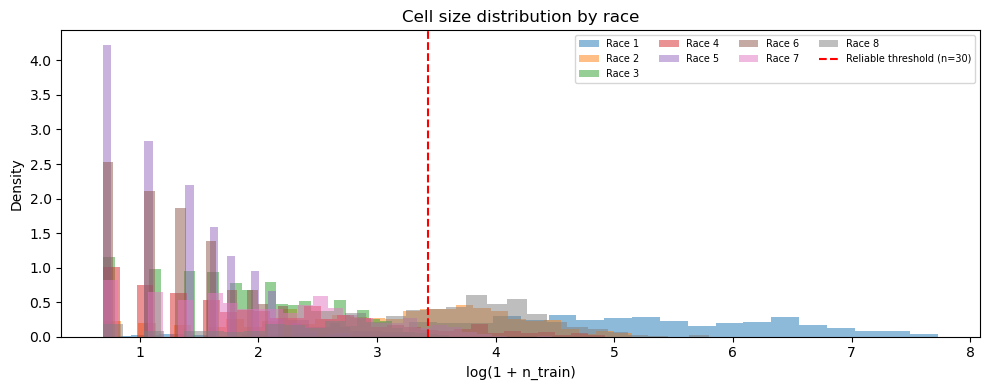

Reliable cells with target prevalences: 1,447
NUM_STATES: 53


In [7]:
# 10 - Sparse Cell Audit
cell_counts = (
    imputed_trains[0].groupby(CELL_COLS).size()
    .reset_index(name="n_train")
)

def classify_cell(n):
    if n >= RELIABLE_N:
        return "reliable"
    if n >= 10:
        return "marginal"
    return "unreliable"

cell_counts["reliability"] = cell_counts["n_train"].map(classify_cell)
print("=== Training cell reliability ===")
print(cell_counts["reliability"].value_counts())
print(f"\nTotal unique cells: {len(cell_counts):,}")

fig, ax = plt.subplots(figsize=(10, 4))
for race, grp in cell_counts.groupby("_RACE"):
    ax.hist(np.log1p(grp["n_train"]), bins=30, alpha=0.5,
            label=f"Race {int(race)}", density=True)
ax.axvline(np.log1p(RELIABLE_N), color="red", linestyle="--",
           label=f"Reliable threshold (n={RELIABLE_N})")
ax.set_xlabel("log(1 + n_train)")
ax.set_ylabel("Density")
ax.set_title("Cell size distribution by race")
ax.legend(fontsize=7, ncol=4)
plt.tight_layout()
plt.show()

def make_cell_key(df_imp):
    return df_imp[CELL_COLS].astype(str).agg("|".join, axis=1)

train_cell_keys = make_cell_key(imputed_trains[0])
cell_map = {k: i for i, k in enumerate(sorted(train_cell_keys.unique()))}
cell_counts["cell_key"] = cell_counts[CELL_COLS].astype(str).agg("|".join, axis=1)
cell_counts["cell_id"] = cell_counts["cell_key"].map(cell_map).astype(int)

reliable_cell_ids = set(
    cell_counts.loc[cell_counts["reliability"] == "reliable", "cell_id"].astype(int).tolist()
)

def map_cell_ids(df_imp):
    return make_cell_key(df_imp).map(cell_map).fillna(-1).astype(int).values

cell_id_train = map_cell_ids(imputed_trains[0])
cell_id_val   = map_cell_ids(imputed_vals[0])
cell_ids_test = [map_cell_ids(imputed_tests[m]) for m in range(MI_DATASETS)]

train_cell_target_df = imputed_trains[0][CELL_COLS].copy()
train_cell_target_df["cell_id"] = cell_id_train
train_cell_target_df["y"] = df_train["obese"].values.astype(float)
train_cell_target_df["w"] = df_train["_LLCPWT_s"].values.astype(float)

train_cell_target_df = (
    train_cell_target_df.groupby("cell_id")
    .apply(lambda g: pd.Series({
        "n_train": len(g),
        "target_prev": np.average(g["y"], weights=g["w"])
    }))
    .reset_index()
)
train_cell_target_df["reliability"] = train_cell_target_df["n_train"].map(classify_cell)
train_cell_target_df = train_cell_target_df[train_cell_target_df["reliability"] == "reliable"].copy()

reliable_target_map = {
    int(r.cell_id): float(r.target_prev)
    for r in train_cell_target_df.itertuples(index=False)
}
print(f"Reliable cells with target prevalences: {len(reliable_target_map):,}")

reliable_ids_sorted = sorted(reliable_target_map.keys())
reliable_index_lookup = np.full(len(cell_map) + 1, -1, dtype=np.int64)
for pos, cid in enumerate(reliable_ids_sorted):
    reliable_index_lookup[cid + 1] = pos

reliable_index_lookup_t = torch.tensor(reliable_index_lookup, dtype=torch.long, device=DEVICE)
reliable_target_tensor = torch.tensor(
    [reliable_target_map[cid] for cid in reliable_ids_sorted],
    dtype=torch.float32,
    device=DEVICE
)

# state encoder for NN
state_le = LabelEncoder()
df_train["state_idx"] = state_le.fit_transform(df_train["_STATE"].fillna(0).astype(int))
df_val["state_idx"]   = state_le.transform(df_val["_STATE"].fillna(0).astype(int))
df_test["state_idx"]  = state_le.transform(df_test["_STATE"].fillna(0).astype(int))
NUM_STATES = len(state_le.classes_)
print(f"NUM_STATES: {NUM_STATES}")

In [8]:
# 11 - Frozen base logistic fits across m=5
y_train = df_train["obese"].values.astype(float)
w_train = df_train["_LLCPWT_s"].values
y_val   = df_val["obese"].values.astype(float)
w_val   = df_val["_LLCPWT_s"].values
y_test  = df_test["obese"].values.astype(float)
w_test  = df_test["_LLCPWT_s"].values

base_models = []
base_logit_trains = []
base_logit_vals = []
base_logit_tests = []

print(f"Fitting frozen logistic base on {MI_DATASETS} imputed datasets...")
for m in range(MI_DATASETS):
    glm = SKLogistic(
        penalty="l2",
        C=BASE_C,
        solver="lbfgs",
        max_iter=BASE_MAX_ITER,
        random_state=SEED
    )
    glm.fit(X_trains_base[m], y_train, sample_weight=w_train)
    base_models.append(glm)

    p_tr = glm.predict_proba(X_trains_base[m])[:, 1]
    p_va = glm.predict_proba(X_vals_base[m])[:, 1]
    p_te = glm.predict_proba(X_tests_base[m])[:, 1]

    eps = 1e-6
    base_logit_trains.append(np.log(np.clip(p_tr, eps, 1-eps) / np.clip(1-p_tr, eps, 1-eps)).astype(np.float32))
    base_logit_vals.append(np.log(np.clip(p_va, eps, 1-eps) / np.clip(1-p_va, eps, 1-eps)).astype(np.float32))
    base_logit_tests.append(np.log(np.clip(p_te, eps, 1-eps) / np.clip(1-p_te, eps, 1-eps)).astype(np.float32))

    auc_m = roc_auc_score(y_val, p_va, sample_weight=w_val)
    brier_m = brier_score_loss(y_val, p_va, sample_weight=w_val)
    print(f"  m={m+1} | val AUC={auc_m:.4f} | val Brier={brier_m:.4f}")

p_base_test = np.mean([1 / (1 + np.exp(-z)) for z in base_logit_tests], axis=0)
auc_base = roc_auc_score(y_test, p_base_test, sample_weight=w_test)
brier_base = brier_score_loss(y_test, p_base_test, sample_weight=w_test)
print("\n=== Frozen Logistic Base - Test Set Metrics ===")
print(f"  Weighted AUC:               {auc_base:.4f}")
print(f"  Weighted Brier:             {brier_base:.4f}")
print(f"  Predicted prevalence:       {np.average(p_base_test, weights=w_test)*100:.2f}%")
print(f"  True prevalence:            {np.average(y_test, weights=w_test)*100:.2f}%")

# Use m=1 covariates for NN training/validation
X_train_demo = X_trains_demo[0]
X_val_demo   = X_vals_demo[0]
base_logit_train = base_logit_trains[0]
base_logit_val   = base_logit_vals[0]
factor_train = factor_trains[0]
factor_val   = factor_vals[0]

Fitting frozen logistic base on 5 imputed datasets...
  m=1 | val AUC=0.6343 | val Brier=0.2116
  m=2 | val AUC=0.6348 | val Brier=0.2115
  m=3 | val AUC=0.6339 | val Brier=0.2116
  m=4 | val AUC=0.6329 | val Brier=0.2118
  m=5 | val AUC=0.6334 | val Brier=0.2117

=== Frozen Logistic Base - Test Set Metrics ===
  Weighted AUC:               0.6230
  Weighted Brier:             0.2129
  Predicted prevalence:       33.25%
  True prevalence:            33.32%


In [9]:
# 12 - Model: explicit cell correction + tiny residual
class FrozenBaseCellNN(nn.Module):
    def __init__(self, input_dim, n_cells, n_states, state_emb_dim=STATE_EMB_DIM,
                 cell_emb_dim=CELL_EMB_DIM, hidden=None, dropout=DROPOUT,
                 residual_scale=RESIDUAL_SCALE):
        super().__init__()
        if hidden is None:
            hidden = HIDDEN_DIMS

        self.residual_scale = residual_scale
        self.state_emb = nn.Embedding(n_states, state_emb_dim)
        self.cell_emb = nn.Embedding(n_cells + 1, cell_emb_dim, padding_idx=0)
        self.cell_delta = nn.Embedding(n_cells + 1, 1, padding_idx=0)

        full_dim = input_dim + state_emb_dim + cell_emb_dim + 1

        self.resid_net = nn.Sequential(
            nn.Linear(full_dim, hidden[0]),
            nn.BatchNorm1d(hidden[0]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden[0], hidden[1]),
            nn.BatchNorm1d(hidden[1]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden[1], 1)
        )

        self.alpha_raw = nn.Parameter(torch.zeros(1))

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

        nn.init.zeros_(self.cell_delta.weight)
        nn.init.zeros_(self.resid_net[-1].weight)
        nn.init.zeros_(self.resid_net[-1].bias)

    def alpha(self):
        return 0.90 + 0.20 * torch.sigmoid(self.alpha_raw)

    def forward(self, x_demo, state_idx, base_logit, cell_id):
        if base_logit.ndim == 1:
            base_logit = base_logit.unsqueeze(1)

        s = self.state_emb(state_idx)
        cell_idx = torch.clamp(cell_id + 1, min=0)
        c = self.cell_emb(cell_idx)

        x = torch.cat([x_demo, s, c, base_logit], dim=1)
        resid_raw = self.resid_net(x).squeeze(-1)
        resid = self.residual_scale * torch.tanh(resid_raw)
        cell_term = self.cell_delta(cell_idx).squeeze(-1)

        logits = self.alpha() * base_logit.squeeze(-1) + cell_term + resid
        return logits, cell_term, resid

    def get_components(self, x_demo, state_idx, base_logit, cell_id):
        logits, cell_term, resid = self.forward(x_demo, state_idx, base_logit, cell_id)
        structured = self.alpha() * base_logit.squeeze(-1) + cell_term
        return structured, resid, logits

def weighted_bce(logits, targets, weights):
    loss = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
    return (loss * weights).mean()

def cell_delta_l2_penalty(model):
    return model.cell_delta.weight[1:].pow(2).mean()

def cell_mean_penalty(logits, targets, weights, cell_ids):
    probs = torch.sigmoid(logits)
    penalties = []
    for cid in torch.unique(cell_ids):
        cid_int = int(cid.item())
        if cid_int < 0 or cid_int not in reliable_cell_ids:
            continue
        mask = (cell_ids == cid)
        if mask.sum().item() < CELL_BATCH_MINN:
            continue
        w_cell = weights[mask]
        p_bar = (probs[mask] * w_cell).sum() / (w_cell.sum() + 1e-8)
        y_bar = (targets[mask] * w_cell).sum() / (w_cell.sum() + 1e-8)
        penalties.append((p_bar - y_bar).pow(2))
    if len(penalties) == 0:
        return torch.tensor(0.0, device=logits.device)
    return torch.stack(penalties).mean()

def make_loader(X_demo, base_logit, y, w, state_idx, cell_id, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X_demo, dtype=torch.float32),
        torch.tensor(base_logit, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
        torch.tensor(w, dtype=torch.float32),
        torch.tensor(state_idx, dtype=torch.long),
        torch.tensor(cell_id, dtype=torch.long),
    )
    return DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        persistent_workers=(NUM_WORKERS > 0),
    )

In [10]:
# 13 - Full-train tensors for reliable-cell reconciliation
full_train_demo_t  = torch.tensor(X_train_demo, dtype=torch.float32, device=DEVICE)
full_train_base_t   = torch.tensor(base_logit_train, dtype=torch.float32, device=DEVICE)
full_train_state_t  = torch.tensor(df_train["state_idx"].values, dtype=torch.long, device=DEVICE)
full_train_cell_t   = torch.tensor(cell_id_train, dtype=torch.long, device=DEVICE)
full_train_y_t      = torch.tensor(df_train["obese"].values.astype(float), dtype=torch.float32, device=DEVICE)
full_train_w_t      = torch.tensor(df_train["_LLCPWT_s"].values.astype(float), dtype=torch.float32, device=DEVICE)

def full_reliable_cell_target_loss(model, chunk_size=32768):
    num = torch.zeros(len(reliable_target_tensor), device=DEVICE)
    den = torch.zeros(len(reliable_target_tensor), device=DEVICE)

    n = len(full_train_y_t)
    for start in range(0, n, chunk_size):
        end = min(start + chunk_size, n)
        Xb = full_train_demo_t[start:end]
        Zb = full_train_base_t[start:end]
        Sb = full_train_state_t[start:end]
        Cb = full_train_cell_t[start:end]
        Wb = full_train_w_t[start:end]

        valid = Cb >= 0
        if valid.sum().item() == 0:
            continue

        Xb = Xb[valid]
        Zb = Zb[valid]
        Sb = Sb[valid]
        Cb = Cb[valid]
        Wb = Wb[valid]

        logits, _, _ = model(Xb, Sb, Zb, Cb)
        probs = torch.sigmoid(logits)

        idx = reliable_index_lookup_t[Cb + 1]
        valid2 = idx >= 0
        if valid2.sum().item() == 0:
            continue

        idx_v = idx[valid2]
        probs_v = probs[valid2]
        W_v = Wb[valid2]

        num = num.index_add(0, idx_v, probs_v * W_v)
        den = den.index_add(0, idx_v, W_v)

    pred_prev = num / (den + 1e-8)
    return (pred_prev - reliable_target_tensor).pow(2).mean()

def run_full_reliable_cell_target_step(model, optimizer):
    optimizer.zero_grad()
    cell_target_loss = full_reliable_cell_target_loss(model)
    loss = FULL_CELL_TARGET_LAMBDA * cell_target_loss
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    return loss.item(), cell_target_loss.item()

@torch.no_grad()
def evaluate_loader(model, loader):
    model.eval()
    all_logits, all_y, all_w, all_c = [], [], [], []
    for X_b, z_b, y_b, w_b, s_b, c_b in loader:
        logits, _, _ = model(X_b.to(DEVICE), s_b.to(DEVICE), z_b.to(DEVICE), c_b.to(DEVICE))
        all_logits.append(logits.cpu())
        all_y.append(y_b)
        all_w.append(w_b)
        all_c.append(c_b)
    logits = torch.cat(all_logits)
    y = torch.cat(all_y)
    w = torch.cat(all_w)
    c = torch.cat(all_c)
    probs = torch.sigmoid(logits).numpy()
    loss = weighted_bce(logits.to(DEVICE), y.to(DEVICE), w.to(DEVICE)).item()
    return probs, logits.numpy(), y.numpy(), w.numpy(), c.numpy(), loss

In [11]:
# 14 - Train
model_nn = FrozenBaseCellNN(
    input_dim=INPUT_DIM,
    n_cells=len(cell_map),
    n_states=NUM_STATES,
    state_emb_dim=STATE_EMB_DIM,
    cell_emb_dim=CELL_EMB_DIM,
    residual_scale=RESIDUAL_SCALE
).to(DEVICE)

print(model_nn)
print(f"nn parameters: {sum(p.numel() for p in model_nn.parameters() if p.requires_grad):,}")

print("=== Epoch 1 gradient norm check ===")
tmp_m = FrozenBaseCellNN(
    input_dim=INPUT_DIM,
    n_cells=len(cell_map),
    n_states=NUM_STATES,
    state_emb_dim=STATE_EMB_DIM,
    cell_emb_dim=CELL_EMB_DIM,
    residual_scale=RESIDUAL_SCALE
).to(DEVICE)
tmp_opt = optim.AdamW(tmp_m.parameters(), lr=LR)
tmp_ldr = make_loader(
    X_train_demo, base_logit_train,
    df_train["obese"].values, df_train["_LLCPWT_s"].values,
    df_train["state_idx"].values, cell_id_train,
    shuffle=True
)

grad_norms = []
for i, (X_b, z_b, y_b, w_b, s_b, c_b) in enumerate(tmp_ldr):
    if i >= 20:
        break
    tmp_opt.zero_grad()
    logits, cell_term, resid = tmp_m(X_b.to(DEVICE), s_b.to(DEVICE), z_b.to(DEVICE), c_b.to(DEVICE))
    loss = (
        weighted_bce(logits, y_b.to(DEVICE), w_b.to(DEVICE))
        + CELL_MEAN_LAMBDA * cell_mean_penalty(logits, y_b.to(DEVICE), w_b.to(DEVICE), c_b.to(DEVICE))
        + CELL_DELTA_L2 * cell_delta_l2_penalty(tmp_m)
        + RESIDUAL_L2_LAMBDA * resid.pow(2).mean()
        + ALPHA_LAMBDA * (tmp_m.alpha() - 1.0).pow(2).mean()
    )
    loss.backward()
    gn = nn.utils.clip_grad_norm_(tmp_m.parameters(), float("inf"))
    grad_norms.append(gn.item())
    tmp_opt.zero_grad()

del tmp_m, tmp_opt
max_gn = max(grad_norms)
USE_WARMUP = max_gn > 10
print(f"  Max gradient norm (first 20 batches): {max_gn:.3f}")
print(f"  Warm-up needed: {USE_WARMUP} (threshold: 10)")

train_loader = make_loader(
    X_train_demo, base_logit_train,
    df_train["obese"].values, df_train["_LLCPWT_s"].values,
    df_train["state_idx"].values, cell_id_train,
    shuffle=True
)
val_loader = make_loader(
    X_val_demo, base_logit_val,
    df_val["obese"].values, df_val["_LLCPWT_s"].values,
    df_val["state_idx"].values, cell_id_val,
    shuffle=False
)

optimizer = optim.AdamW(model_nn.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

if USE_WARMUP:
    WARMUP = 5
    def lr_lambda(ep):
        return (ep + 1) / WARMUP if ep < WARMUP else \
               0.5 * (1 + np.cos(np.pi * (ep - WARMUP) / (MAX_EPOCHS - WARMUP)))
    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
else:
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

history = {"train_loss": [], "val_loss": [], "val_auc": []}
best_score, best_state, no_improve = np.inf, None, 0

print(f"{'Epoch':>5} {'Train':>10} {'Val':>10} {'AUC':>8} {'LR':>10}")
print("-" * 50)

for epoch in range(1, MAX_EPOCHS + 1):
    model_nn.train()
    total_loss, total_n = 0.0, 0

    for X_b, z_b, y_b, w_b, s_b, c_b in train_loader:
        X_b = X_b.to(DEVICE)
        z_b = z_b.to(DEVICE)
        y_b = y_b.to(DEVICE)
        w_b = w_b.to(DEVICE)
        s_b = s_b.to(DEVICE)
        c_b = c_b.to(DEVICE)

        optimizer.zero_grad()
        logits, cell_term, resid = model_nn(X_b, s_b, z_b, c_b)

        bce = weighted_bce(logits, y_b, w_b)
        cell_pen = cell_mean_penalty(logits, y_b, w_b, c_b)
        cell_delta_pen = cell_delta_l2_penalty(model_nn)
        resid_l2 = resid.pow(2).mean()
        alpha_pen = (model_nn.alpha() - 1.0).pow(2).mean()

        loss = (
            bce
            + CELL_MEAN_LAMBDA * cell_pen
            + CELL_DELTA_L2 * cell_delta_pen
            + RESIDUAL_L2_LAMBDA * resid_l2
            + ALPHA_LAMBDA * alpha_pen
        )
        loss.backward()
        nn.utils.clip_grad_norm_(model_nn.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * len(y_b)
        total_n += len(y_b)

    tr_loss = total_loss / total_n

    recon_total = 0.0
    recon_core = 0.0
    for _ in range(FULL_CELL_TARGET_STEPS):
        rt, rc = run_full_reliable_cell_target_step(model_nn, optimizer)
        recon_total += rt
        recon_core += rc
    recon_total /= FULL_CELL_TARGET_STEPS
    recon_core /= FULL_CELL_TARGET_STEPS

    probs_v, logits_v, y_v, w_v, c_v, val_loss = evaluate_loader(model_nn, val_loader)
    val_auc = roc_auc_score(y_v, probs_v, sample_weight=w_v)
    val_cell_pen = cell_mean_penalty(
        torch.tensor(logits_v, dtype=torch.float32, device=DEVICE),
        torch.tensor(y_v, dtype=torch.float32, device=DEVICE),
        torch.tensor(w_v, dtype=torch.float32, device=DEVICE),
        torch.tensor(c_v, dtype=torch.long, device=DEVICE),
    ).item()
    val_score = val_loss + EARLY_STOP_CELL_WEIGHT * val_cell_pen

    scheduler.step()
    lr_now = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["val_auc"].append(val_auc)

    if epoch % 10 == 0 or epoch == 1:
        print(f"{epoch:>5} {tr_loss:>10.5f} {val_loss:>10.5f} {val_auc:>8.4f} {lr_now:>10.2e} | cell={val_cell_pen:.5f}")

    if val_score < best_score - 1e-5:
        best_score = val_score
        best_state = {k: v.cpu().clone() for k, v in model_nn.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"\nEarly stop at epoch {epoch} | best val score {best_score:.5f}")
            break

model_nn.load_state_dict(best_state)
print(f"\nBest weights restored | val score: {best_score:.5f}")

probs_tr, logits_tr, y_tr, w_tr, c_tr, _ = evaluate_loader(
    model_nn,
    make_loader(
        X_train_demo, base_logit_train,
        df_train["obese"].values, df_train["_LLCPWT_s"].values,
        df_train["state_idx"].values, cell_id_train,
        shuffle=False
    )
)
loss_w = brier_score_loss(y_tr, probs_tr, sample_weight=w_tr)
loss_uw = brier_score_loss(y_tr, probs_tr)
print(f"Weighted Brier (train):   {loss_w:.4f}")
print(f"Unweighted Brier (train): {loss_uw:.4f}")
if abs(loss_w - loss_uw) > 0.05:
    print("WARNING: Large divergence - consider reducing trim to p95")

FrozenBaseCellNN(
  (state_emb): Embedding(53, 4)
  (cell_emb): Embedding(5168, 6, padding_idx=0)
  (cell_delta): Embedding(5168, 1, padding_idx=0)
  (resid_net): Sequential(
    (0): Linear(in_features=47, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.03, inplace=False)
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.03, inplace=False)
    (8): Linear(in_features=16, out_features=1, bias=True)
  )
)
nn parameters: 38,566
=== Epoch 1 gradient norm check ===
  Max gradient norm (first 20 batches): 0.044
  Warm-up needed: False (threshold: 10)
Epoch      Train        Val      AUC         LR
--------------------------------------------------
    1    0.69802    0.61249   0.6350   8.00e-04 | cell=0.03075
   10    0.69044    0.61179   0.6360   7.80e

In [12]:
# 15 - Temperature scaling on pooled validation logits
class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.logT = nn.Parameter(torch.zeros(1, device=DEVICE))

    @property
    def T(self):
        return torch.exp(self.logT)

    def fit_from_logits(self, logits_np, y_np, w_np, max_iter=50):
        logits = torch.tensor(logits_np, dtype=torch.float32, device=DEVICE)
        y = torch.tensor(y_np, dtype=torch.float32, device=DEVICE)
        w = torch.tensor(w_np, dtype=torch.float32, device=DEVICE)

        opt = torch.optim.LBFGS([self.logT], max_iter=max_iter, lr=0.01)

        def closure():
            opt.zero_grad()
            loss = weighted_bce(logits / self.T, y, w)
            loss.backward()
            return loss

        opt.step(closure)
        return self

    def apply(self, logits_np):
        with torch.no_grad():
            logits = torch.tensor(logits_np, dtype=torch.float32, device=DEVICE)
            return torch.sigmoid(logits / self.T).detach().cpu().numpy()

val_logits_per_m = []
for m_idx in range(MI_DATASETS):
    Xv_demo_t = torch.tensor(X_vals_demo[m_idx], dtype=torch.float32, device=DEVICE)
    Zv_t = torch.tensor(base_logit_vals[m_idx], dtype=torch.float32, device=DEVICE)
    Sv_t = torch.tensor(df_val["state_idx"].values, dtype=torch.long, device=DEVICE)
    c_vt = torch.tensor(cell_id_val, dtype=torch.long, device=DEVICE)

    with torch.no_grad():
        lv, _, _ = model_nn(Xv_demo_t, Sv_t, Zv_t, c_vt)
        lv = lv.cpu().numpy()
    val_logits_per_m.append(lv)

val_logits_mean = np.mean(val_logits_per_m, axis=0)

scaler = TemperatureScaler().to(DEVICE)
scaler.fit_from_logits(val_logits_mean, y_val, w_val)
T_val = scaler.T.item()
print(f"Temperature T = {T_val:.4f}")

Temperature T = 1.0000


In [13]:
# 16 - Nonlinearity diagnostic (structured baseline vs residual)
model_nn.eval()
N_DIAG = min(5000, len(df_test))
X_samp = torch.tensor(X_tests_demo[0][:N_DIAG], dtype=torch.float32, device=DEVICE)
s_samp = torch.tensor(df_test["state_idx"].values[:N_DIAG], dtype=torch.long, device=DEVICE)
z_samp = torch.tensor(base_logit_tests[0][:N_DIAG], dtype=torch.float32, device=DEVICE)
c_samp = torch.tensor(cell_ids_test[0][:N_DIAG], dtype=torch.long, device=DEVICE)

with torch.no_grad():
    base_part, resid_part, total = model_nn.get_components(X_samp, s_samp, z_samp, c_samp)
    structured = base_part.cpu()
    resid_part = resid_part.cpu()
    total = total.cpu()

structured_c = structured - structured.mean()
resid_c = resid_part - resid_part.mean()
proj = torch.dot(resid_c.flatten(), structured_c.flatten()) / (torch.dot(structured_c.flatten(), structured_c.flatten()) + 1e-8)
resid_orth = resid_c - proj * structured_c
var_struct = structured_c.var().item()
var_resid = resid_orth.var().item()
var_total = (total - total.mean()).var().item()
cov_share = 1.0 - (var_struct + var_resid) / (var_total + 1e-8)

print("=== Variance Decomposition of Logit Predictions ===")
print(f"  Structured baseline share:     {var_struct/var_total:.3f}")
print(f"  Orthogonal residual share:     {var_resid/var_total:.3f}")
print(f"  Cross-term (covariance) share: {cov_share:.3f}")
resid_pct = var_resid / var_total * 100
if resid_pct < 5:
    print(f"\n  {resid_pct:.1f}% residual -> structure dominates")
elif resid_pct < 20:
    print(f"\n  {resid_pct:.1f}% residual -> small NN component justified")
else:
    print(f"\n  {resid_pct:.1f}% residual -> NN clearly doing a lot")

=== Variance Decomposition of Logit Predictions ===
  Structured baseline share:     0.998
  Orthogonal residual share:     0.000
  Cross-term (covariance) share: 0.001

  0.0% residual -> structure dominates


In [14]:
# 17 - nn Test Evaluation (Prediction Pooling across m=5)
y_test_arr = df_test["obese"].values.astype(float)
w_test_arr = df_test["_LLCPWT_s"].values

p_nn_per_m = []
for m_idx in range(MI_DATASETS):
    Xm_demo_t = torch.tensor(X_tests_demo[m_idx], dtype=torch.float32, device=DEVICE)
    Zm_t = torch.tensor(base_logit_tests[m_idx], dtype=torch.float32, device=DEVICE)
    Sm_t = torch.tensor(df_test["state_idx"].values, dtype=torch.long, device=DEVICE)
    Cm_t = torch.tensor(cell_ids_test[m_idx], dtype=torch.long, device=DEVICE)

    with torch.no_grad():
        logits_m, _, _ = model_nn(Xm_demo_t, Sm_t, Zm_t, Cm_t)
        logits_m = logits_m.cpu().numpy()
    p_nn_per_m.append(scaler.apply(logits_m))

p_nn_test = np.mean(p_nn_per_m, axis=0)
p_mi_std = np.std(p_nn_per_m, axis=0)
auc_nn = roc_auc_score(y_test_arr, p_nn_test, sample_weight=w_test_arr)
brier_nn = brier_score_loss(y_test_arr, p_nn_test, sample_weight=w_test_arr)
prev_pred_f = np.average(p_nn_test, weights=w_test_arr) * 100
prev_true = np.average(y_test_arr, weights=w_test_arr) * 100

print("=== nn - Test Set Metrics ===")
print(f"  Weighted AUC:               {auc_nn:.4f}")
print(f"  Weighted Brier:             {brier_nn:.4f}")
print(f"  Predicted prevalence:       {prev_pred_f:.2f}%")
print(f"  True prevalence:            {prev_true:.2f}%")
print(f"  Prevalence gap:             {abs(prev_pred_f - prev_true):.2f}pp")
print(f"  Mean between-imputation SD: {p_mi_std.mean():.4f}")

=== nn - Test Set Metrics ===
  Weighted AUC:               0.6273
  Weighted Brier:             0.2123
  Predicted prevalence:       33.14%
  True prevalence:            33.32%
  Prevalence gap:             0.18pp
  Mean between-imputation SD: 0.0054


In [15]:
# 18 - Cell-Level Calibration
def cell_calibration(p_hat, y, w, df_split, df_imp, label="Model"):
    cdf = df_imp[CELL_COLS].copy()
    cdf["p_hat"] = p_hat
    cdf["y"] = y
    cdf["w"] = w
    records = []

    for cell, grp in cdf.groupby(CELL_COLS):
        n = len(grp)
        pred_prev = np.average(grp["p_hat"], weights=grp["w"])
        true_prev = np.average(grp["y"], weights=grp["w"])
        slope = np.nan
        if n >= RELIABLE_N and grp["y"].nunique() > 1:
            lp = np.log(grp["p_hat"].clip(1e-6, 1-1e-6) / (1 - grp["p_hat"].clip(1e-6, 1-1e-6)))
            try:
                cm = SKLogistic(
                    penalty="l2",
                    C=1e6,
                    solver="lbfgs",
                    max_iter=200
                ).fit(
                    lp.values.reshape(-1, 1),
                    grp["y"].values,
                    sample_weight=grp["w"].values
                )
                slope = cm.coef_[0][0]
            except Exception:
                pass
        records.append({
            "cell": cell,
            "n": n,
            "pred_prev": pred_prev,
            "true_prev": true_prev,
            "error": pred_prev - true_prev,
            "cal_slope": slope,
            "reliability": classify_cell(n)
        })

    result = pd.DataFrame(records)
    rel = result[result["reliability"] == "reliable"]
    marg = result[result["reliability"] == "marginal"]

    print(f"\n=== {label} - Cell Calibration ===")
    print(f"  Reliable cells (n>={RELIABLE_N}): {len(rel):,}")
    if len(rel):
        print(f"    Mean |error|:   {rel['error'].abs().mean()*100:.2f}pp")
        slopes = rel["cal_slope"].dropna()
        if len(slopes):
            print(f"    Slopes: mean={slopes.mean():.3f} std={slopes.std():.3f} (ideal=1.0)")
            if slopes.mean() < 0.85:
                print("    WARNING: overconfident calibration")
            if slopes.mean() > 1.15:
                print("    WARNING: underconfident calibration")
    print(f"  Marginal cells (10-{RELIABLE_N}): {len(marg):,}")
    if len(marg):
        print(f"    Mean |error|: {marg['error'].abs().mean()*100:.2f}pp")
    return result

cell_cal_nn = cell_calibration(p_nn_test, y_test_arr, w_test_arr, df_test, imputed_tests[0], "nn")


=== nn - Cell Calibration ===
  Reliable cells (n>=30): 389
    Mean |error|:   7.60pp
    Slopes: mean=1.282 std=3.763 (ideal=1.0)
  Marginal cells (10-30): 724
    Mean |error|: 16.11pp



=== nn - State Validation ===
  Pred vs True corr:   0.8335
  Mean |error|:        2.10pp
  Max |error|:         12.80pp
  States |err|>3pp:    11

=== nn - Subgroup AUC by Race ===
  NH-White             n=45,865  AUC=0.6160
  NH-Black             n= 4,866  AUC=0.5857
  AIAN                 n= 1,031  AUC=0.5638
  Asian                n= 1,795  AUC=0.6174
  NHOPI                n=   357  AUC=0.5381 WARNING AUC<0.55
  Other                n=   520  AUC=0.6409
  Multiracial          n= 1,486  AUC=0.6041
  Hispanic             n= 6,260  AUC=0.5891
=== ACS Distribution Shift Test ===
  nn: Brier(BRFSS)=0.2123  Brier(ACS-shifted)=0.2146  gap=0.0023 OK
Race                  n    q_hat Note
NH-White          45874   0.6973
NH-Black           4869   0.6271
AIAN               1037   0.6584
Asian              1793   0.8159
NHOPI               356   0.6579
Other               518   0.7030
Multiracial        1472   0.6966
Hispanic           6261   0.6612

=== Race-Conditional Coverage (target >= 

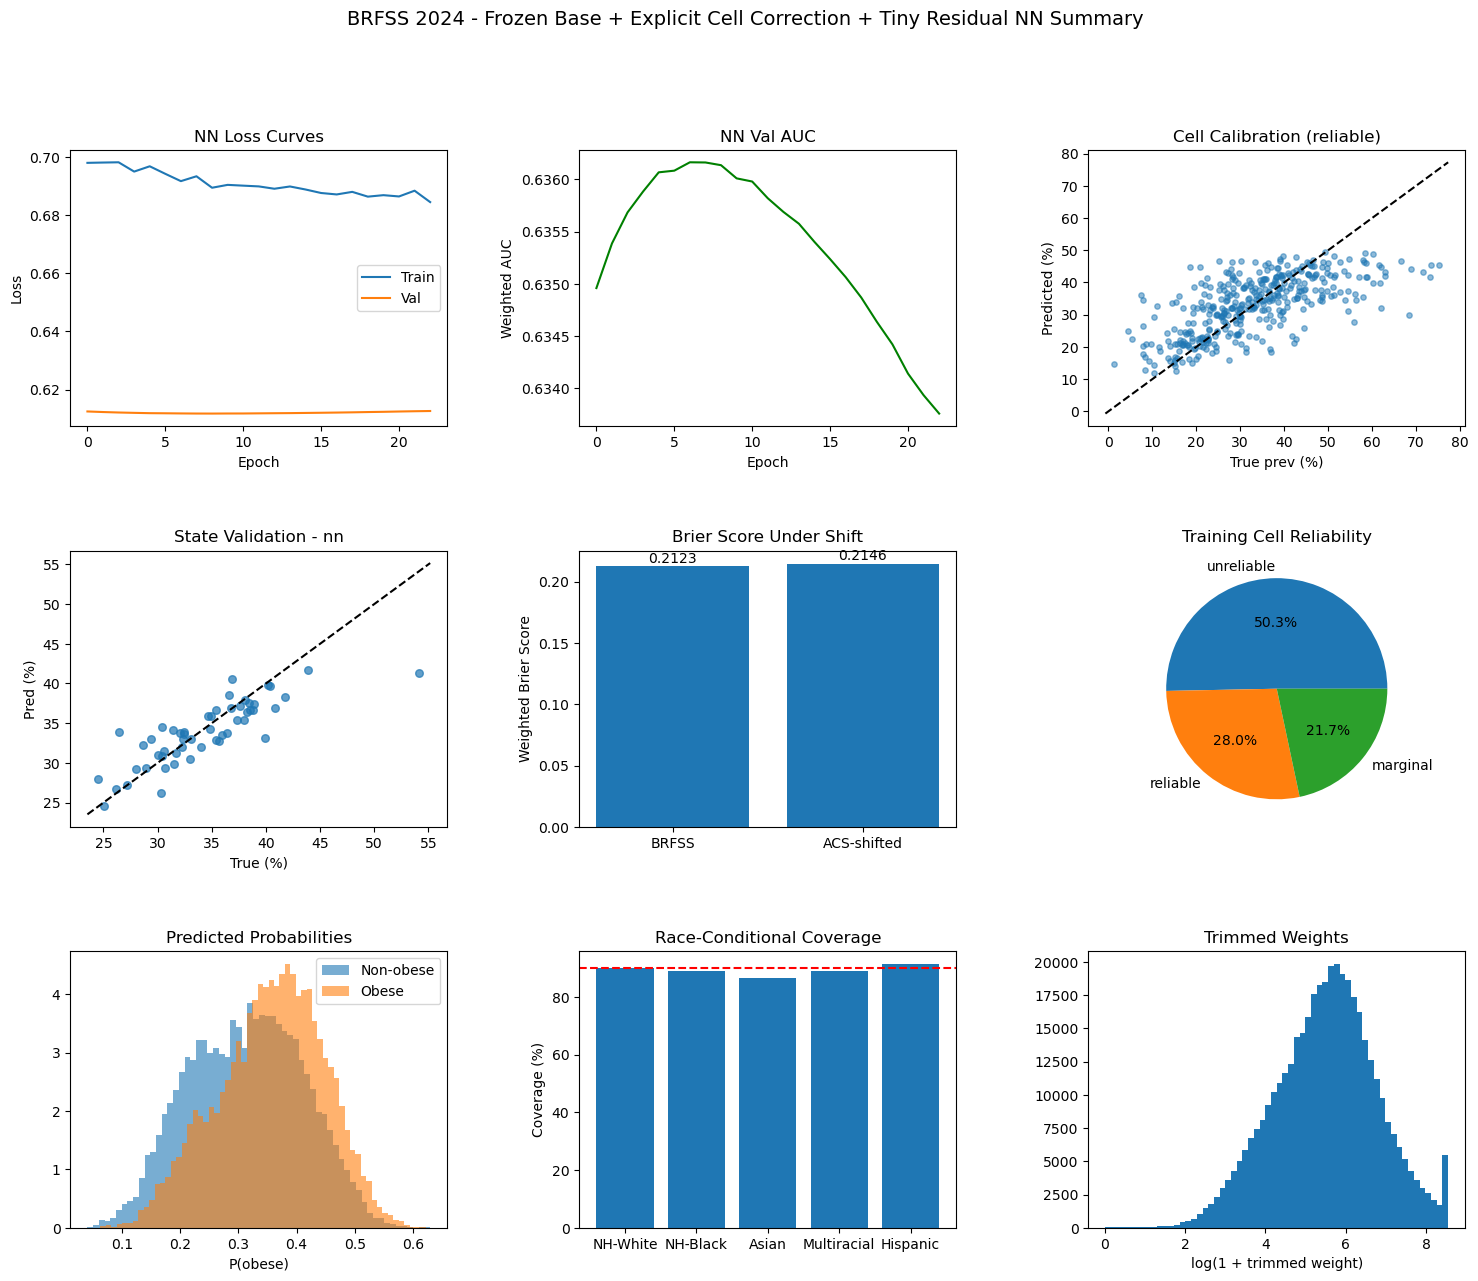

Saved: brfss_cellhead_nn_results.png
Saved:
  brfss_nn.pt
  brfss_encoder.pkl
  brfss_cell_reliability.csv
  brfss_race_coverage.csv
  brfss_metrics.json
  brfss_cellhead_nn_results.png


In [16]:
# 19 - State-Level Validation
def state_validation(p_hat, y, w, states, label="Model"):
    df_s = pd.DataFrame({"p": p_hat, "y": y, "w": w, "state": states})
    grp = df_s.groupby("state").apply(lambda g: pd.Series({
        "pred": np.average(g["p"], weights=g["w"]) * 100,
        "true": np.average(g["y"], weights=g["w"]) * 100,
        "n": len(g)
    })).reset_index()
    grp["residual"] = grp["pred"] - grp["true"]
    corr = grp[["pred", "true"]].corr().iloc[0, 1]
    mae = grp["residual"].abs().mean()
    print(f"\n=== {label} - State Validation ===")
    print(f"  Pred vs True corr:   {corr:.4f}")
    print(f"  Mean |error|:        {mae:.2f}pp")
    print(f"  Max |error|:         {grp['residual'].abs().max():.2f}pp")
    print(f"  States |err|>3pp:    {(grp['residual'].abs()>3).sum()}")
    return grp

state_nn = state_validation(p_nn_test, y_test_arr, w_test_arr, df_test["_STATE"].values, "nn")

# 20 - Subgroup AUC by Race
def subgroup_auc(p_hat, y, w, df_imp, label="Model"):
    race_col = df_imp["_RACE"].values
    print(f"\n=== {label} - Subgroup AUC by Race ===")
    for code, name in RACE_LABELS.items():
        mask = race_col == code
        n = mask.sum()
        if n < 50:
            print(f"  {name:20s} n={n:>6}  SKIPPED (n<50 - sparse)")
            continue
        if y[mask].max() == y[mask].min():
            print(f"  {name:20s} n={n:>6}  ERROR (single class)")
            continue
        sub_auc = roc_auc_score(y[mask], p_hat[mask], sample_weight=w[mask])
        flag = " WARNING AUC<0.55" if sub_auc < 0.55 else ""
        print(f"  {name:20s} n={n:>6,}  AUC={sub_auc:.4f}{flag}")

subgroup_auc(p_nn_test, y_test_arr, w_test_arr, imputed_tests[0], "nn")

# 21 - ACS Distribution Shift Test
ACS_MARGINALS = {
    "_SEX":    {1: 0.487, 2: 0.513},
    "_EDUCAG": {1: 0.088, 2: 0.270, 3: 0.290, 4: 0.352},
    "_RACE":   {1: 0.596, 2: 0.121, 3: 0.009, 4: 0.060, 5: 0.002, 6: 0.049, 7: 0.030, 8: 0.133},
}

def compute_shift_weights(df_imp):
    rng = np.random.RandomState(SEED)
    n = len(df_imp)
    acs_sim = {}
    for col, dist in ACS_MARGINALS.items():
        codes = list(dist.keys())
        probs = np.array(list(dist.values()))
        probs /= probs.sum()
        acs_sim[col] = rng.choice(codes, size=n, p=probs)
    df_acs = pd.DataFrame(acs_sim)
    brfss_enc = pd.get_dummies(df_imp[list(ACS_MARGINALS.keys())]).astype(float)
    acs_enc = pd.get_dummies(df_acs).reindex(columns=brfss_enc.columns, fill_value=0)
    X_comb = np.vstack([brfss_enc.values, acs_enc.values])
    y_comb = np.concatenate([np.zeros(n), np.ones(n)])
    clf = SKLogistic(max_iter=500, C=1.0).fit(X_comb, y_comb)
    log_odds = clf.predict_log_proba(brfss_enc.values)
    sw = np.exp(log_odds[:, 1] - log_odds[:, 0])
    return sw / sw.mean()

shift_w = compute_shift_weights(imputed_tests[0])

print("=== ACS Distribution Shift Test ===")
w_comb = w_test_arr * shift_w
w_comb /= w_comb.mean()
brier_brfss_nn = brier_score_loss(y_test_arr, p_nn_test, sample_weight=w_test_arr)
brier_acs_nn = brier_score_loss(y_test_arr, p_nn_test, sample_weight=w_comb)
gap = abs(brier_acs_nn - brier_brfss_nn)
flag = " WARNING: large shift gap" if gap > 0.01 else " OK"
print(f"  nn: Brier(BRFSS)={brier_brfss_nn:.4f}  Brier(ACS-shifted)={brier_acs_nn:.4f}  gap={gap:.4f}{flag}")

###
# 22 - Race-Conditional Conformal Prediction
X_val_t_demo = torch.tensor(X_val_demo, dtype=torch.float32, device=DEVICE)
Z_val_t = torch.tensor(base_logit_val, dtype=torch.float32, device=DEVICE)
S_val_t = torch.tensor(df_val["state_idx"].values, dtype=torch.long, device=DEVICE)
C_val_t = torch.tensor(cell_id_val, dtype=torch.long, device=DEVICE)

with torch.no_grad():
    logits_val_final, _, _ = model_nn(
        X_val_t_demo,
        S_val_t,
        Z_val_t,
        C_val_t,
    )
p_val = scaler.apply(logits_val_final.cpu().numpy())

y_val_np = df_val["obese"].values.astype(float)
race_val = imputed_vals[0]["_RACE"].values.astype(int)

q_hat_global = np.quantile(
    np.abs(y_val_np - p_val),
    np.ceil((len(y_val_np) + 1) * (1 - ALPHA_CONFORMAL)) / len(y_val_np)
)

q_hat_by_race = {}
print(f'{"Race":15s} {"n":>7} {"q_hat":>8} {"Note"}')
for rc in range(1, 9):
    mask = race_val == rc
    n_r = mask.sum()
    if n_r < 100:
        q_hat_by_race[rc] = q_hat_global
        print(f"{RACE_LABELS[rc]:15s} {n_r:>7} {q_hat_global:>8.4f}  fallback to global")
        continue
    scores = np.abs(y_val_np[mask] - p_val[mask])
    q_r = np.quantile(scores, np.ceil((n_r + 1) * (1 - ALPHA_CONFORMAL)) / n_r)
    q_hat_by_race[rc] = q_r
    print(f"{RACE_LABELS[rc]:15s} {n_r:>7} {q_r:>8.4f}")

race_test = imputed_tests[0]["_RACE"].values.astype(int)
cell_n_test = (
    imputed_tests[0]
    .merge(cell_counts[CELL_COLS + ["n_train"]], on=CELL_COLS, how="left")["n_train"]
    .fillna(0).values
)

lo_arr, hi_arr, flag_arr = [], [], []
for p, rc, n_tr in zip(p_nn_test, race_test, cell_n_test):
    q = q_hat_by_race.get(int(rc), q_hat_global)
    if n_tr < 10:
        lo_arr.append(np.nan)
        hi_arr.append(np.nan)
        flag_arr.append("unreliable")
    else:
        lo_arr.append(np.clip(p - q, 0, 1))
        hi_arr.append(np.clip(p + q, 0, 1))
        flag_arr.append("marginal" if n_tr < RELIABLE_N else "reliable")

lo_test, hi_test, flag_test = np.array(lo_arr), np.array(hi_arr), np.array(flag_arr)

race_cov_rows = []
print(f"\n=== Race-Conditional Coverage (target >= {(1-ALPHA_CONFORMAL)*100:.0f}%) ===")
for rc, name in RACE_LABELS.items():
    mask = (race_test == rc) & (flag_test == "reliable")
    if mask.sum() < 50:
        continue
    covered = ((y_test_arr[mask] >= lo_test[mask]) & (y_test_arr[mask] <= hi_test[mask])).mean()
    ok = "OK" if covered >= (1 - ALPHA_CONFORMAL) else "BELOW TARGET"
    race_cov_rows.append({"race": name, "coverage": covered, "n": int(mask.sum())})
    print(f"  {name:15s}: {covered*100:.1f}%  n={mask.sum():,}  {ok}")

race_cov_df = pd.DataFrame(race_cov_rows)

# 23 - Permutation importance
try:
    print("Computing permutation-style feature importance...")
    base_auc_val = roc_auc_score(y_val_np, p_val, sample_weight=df_val["_LLCPWT_s"].values)

    rng_perm = np.random.RandomState(SEED)
    perm_rows = []
    C_val_t = torch.tensor(cell_id_val, dtype=torch.long, device=DEVICE)

    # Permute demographic one-hot input
    Xp_demo = X_val_demo.copy()
    perm = rng_perm.permutation(len(Xp_demo))
    Xp_demo = Xp_demo[perm]
    with torch.no_grad():
        lp, _, _ = model_nn(
            torch.tensor(Xp_demo, dtype=torch.float32, device=DEVICE),
            torch.tensor(df_val["state_idx"].values, dtype=torch.long, device=DEVICE),
            torch.tensor(base_logit_val, dtype=torch.float32, device=DEVICE),
            C_val_t,
        )
    p_perm = scaler.apply(lp.cpu().numpy())
    auc_perm = roc_auc_score(y_val_np, p_perm, sample_weight=df_val["_LLCPWT_s"].values)
    perm_rows.append({"feature": "demo_onehot", "delta_auc": base_auc_val - auc_perm})

    # Permute state
    state_perm = rng_perm.permutation(df_val["state_idx"].values)
    with torch.no_grad():
        lp, _, _ = model_nn(
            torch.tensor(X_val_demo, dtype=torch.float32, device=DEVICE),
            torch.tensor(state_perm, dtype=torch.long, device=DEVICE),
            torch.tensor(base_logit_val, dtype=torch.float32, device=DEVICE),
            C_val_t,
        )
    p_perm = scaler.apply(lp.cpu().numpy())
    auc_perm = roc_auc_score(y_val_np, p_perm, sample_weight=df_val["_LLCPWT_s"].values)
    perm_rows.append({"feature": "state_idx", "delta_auc": base_auc_val - auc_perm})

    # Permute frozen base logit
    z_perm = rng_perm.permutation(base_logit_val)
    with torch.no_grad():
        lp, _, _ = model_nn(
            torch.tensor(X_val_demo, dtype=torch.float32, device=DEVICE),
            torch.tensor(df_val["state_idx"].values, dtype=torch.long, device=DEVICE),
            torch.tensor(z_perm, dtype=torch.float32, device=DEVICE),
            C_val_t,
        )
    p_perm = scaler.apply(lp.cpu().numpy())
    auc_perm = roc_auc_score(y_val_np, p_perm, sample_weight=df_val["_LLCPWT_s"].values)
    perm_rows.append({"feature": "base_logit", "delta_auc": base_auc_val - auc_perm})

    # Optional: permute cell id too
    cell_perm = rng_perm.permutation(cell_id_val)
    with torch.no_grad():
        lp, _, _ = model_nn(
            torch.tensor(X_val_demo, dtype=torch.float32, device=DEVICE),
            torch.tensor(df_val["state_idx"].values, dtype=torch.long, device=DEVICE),
            torch.tensor(base_logit_val, dtype=torch.float32, device=DEVICE),
            torch.tensor(cell_perm, dtype=torch.long, device=DEVICE),
        )
    p_perm = scaler.apply(lp.cpu().numpy())
    auc_perm = roc_auc_score(y_val_np, p_perm, sample_weight=df_val["_LLCPWT_s"].values)
    perm_rows.append({"feature": "cell_id", "delta_auc": base_auc_val - auc_perm})

    perm_df = pd.DataFrame(perm_rows).sort_values("delta_auc", ascending=False)
    print("\n=== Permutation Importance (validation AUC drop) ===")
    print(perm_df.to_string(index=False))

except Exception as e:
    print(f"Permutation importance failed: {e}")
    perm_df = pd.DataFrame()
    
# 24 - Final nn Snapshot
print("=== FINAL NN MODEL SNAPSHOT ===")
print(f"Weighted AUC:   {auc_nn:.4f}")
print(f"Weighted Brier: {brier_nn:.4f}")
reliable_cells = cell_cal_nn[cell_cal_nn["reliability"] == "reliable"]
marginal_cells = cell_cal_nn[cell_cal_nn["reliability"] == "marginal"]
print(f"Reliable-cell mean |error|: {reliable_cells['error'].abs().mean()*100:.2f}pp")
print(f"Marginal-cell mean |error|:  {marginal_cells['error'].abs().mean()*100:.2f}pp")
if reliable_cells["cal_slope"].notna().any():
    print(f"Reliable-cell calibration slope mean: {reliable_cells['cal_slope'].dropna().mean():.3f}")

# 25 - Summary Plots
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle("BRFSS 2024 - Frozen Base + Explicit Cell Correction + Tiny Residual NN Summary", fontsize=14)

ax = fig.add_subplot(gs[0, 0])
ax.plot(history["train_loss"], label="Train")
ax.plot(history["val_loss"], label="Val")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("NN Loss Curves")
ax.legend()

ax = fig.add_subplot(gs[0, 1])
ax.plot(history["val_auc"], color="green")
ax.set_xlabel("Epoch")
ax.set_ylabel("Weighted AUC")
ax.set_title("NN Val AUC")

ax = fig.add_subplot(gs[0, 2])
rel = cell_cal_nn[cell_cal_nn["reliability"] == "reliable"]
if len(rel):
    ax.scatter(rel["true_prev"]*100, rel["pred_prev"]*100, s=15, alpha=0.5)
    mn = min(rel["true_prev"].min(), rel["pred_prev"].min())*100 - 2
    mx = max(rel["true_prev"].max(), rel["pred_prev"].max())*100 + 2
    ax.plot([mn, mx], [mn, mx], "k--")
ax.set_xlabel("True prev (%)")
ax.set_ylabel("Predicted (%)")
ax.set_title("Cell Calibration (reliable)")

ax = fig.add_subplot(gs[1, 0])
ax.scatter(state_nn["true"], state_nn["pred"], s=30, alpha=0.7)
mn = min(state_nn[["true", "pred"]].min()) - 1
mx = max(state_nn[["true", "pred"]].max()) + 1
ax.plot([mn, mx], [mn, mx], "k--")
ax.set_xlabel("True (%)")
ax.set_ylabel("Pred (%)")
ax.set_title("State Validation - nn")

ax = fig.add_subplot(gs[1, 1])
bars = ax.bar(["BRFSS", "ACS-shifted"], [brier_brfss_nn, brier_acs_nn])
ax.set_ylabel("Weighted Brier Score")
ax.set_title("Brier Score Under Shift")
for bar, b in zip(bars, [brier_brfss_nn, brier_acs_nn]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, f"{b:.4f}",
            ha="center", va="bottom")

ax = fig.add_subplot(gs[1, 2])
rc = cell_counts["reliability"].value_counts()
ax.pie(rc.values, labels=rc.index, autopct="%1.1f%%")
ax.set_title("Training Cell Reliability")

ax = fig.add_subplot(gs[2, 0])
ax.hist(p_nn_test[y_test_arr == 0], bins=60, alpha=0.6, label="Non-obese", density=True)
ax.hist(p_nn_test[y_test_arr == 1], bins=60, alpha=0.6, label="Obese", density=True)
ax.set_xlabel("P(obese)")
ax.set_title("Predicted Probabilities")
ax.legend()

ax = fig.add_subplot(gs[2, 1])
if len(race_cov_df):
    ax.bar(race_cov_df["race"], race_cov_df["coverage"]*100)
    ax.axhline((1-ALPHA_CONFORMAL)*100, linestyle="--", color="red")
    ax.set_ylabel("Coverage (%)")
    ax.set_title("Race-Conditional Coverage")

ax = fig.add_subplot(gs[2, 2])
ax.hist(np.log1p(df["_LLCPWT_trimmed"]), bins=60, edgecolor="none")
ax.set_xlabel("log(1 + trimmed weight)")
ax.set_title("Trimmed Weights")

plt.savefig("brfss_cellhead_nn_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: brfss_cellhead_nn_results.png")

# 26 - Save Artifacts
import pickle
import json

torch.save({
    "model_state": model_nn.state_dict(),
    "temperature": scaler.T.item(),
    "q_hat_by_race": q_hat_by_race,
    "q_hat_global": q_hat_global,
    "auc": auc_nn,
    "brier": brier_nn,
    "DEFF": DEFF,
    "num_states": NUM_STATES,
    "input_dim": INPUT_DIM,
    "hidden_dims": HIDDEN_DIMS,
    "dropout": DROPOUT,
    "state_emb_dim": STATE_EMB_DIM,
    "cell_emb_dim": CELL_EMB_DIM,
    "base_c": BASE_C,
    "residual_scale": RESIDUAL_SCALE,
    "cell_delta_l2": CELL_DELTA_L2,
    "cell_mean_lambda": CELL_MEAN_LAMBDA,
    "full_cell_target_lambda": FULL_CELL_TARGET_LAMBDA,
    "full_cell_target_steps": FULL_CELL_TARGET_STEPS,
}, "brfss_nn.pt")

with open("brfss_encoder.pkl", "wb") as f:
    pickle.dump({
        "demo_encoder": encoder,
        "base_encoder": base_encoder,
        "state_le": state_le,
        "cell_map": cell_map
    }, f)

cell_counts.to_csv("brfss_cell_reliability.csv", index=False)
race_cov_df.to_csv("brfss_race_coverage.csv", index=False)

metrics = {
    "base_logistic": {
        "auc": round(auc_base, 4),
        "brier": round(brier_base, 4)
    },
    "nn": {
        "auc": round(auc_nn, 4),
        "brier": round(brier_nn, 4),
        "temperature": round(scaler.T.item(), 4),
        "DEFF": round(DEFF, 3)
    }
}
with open("brfss_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved:")
print("  brfss_nn.pt")
print("  brfss_encoder.pkl")
print("  brfss_cell_reliability.csv")
print("  brfss_race_coverage.csv")
print("  brfss_metrics.json")
print("  brfss_cellhead_nn_results.png")